<h1><strong>Tokenization</strong></h1>

Tokenization is at the heart of much weirdness of LLMs. Do not brush it off.

• Why can't LLM spell words? Tokenization. \
• Why can't LLM do super simple string processing tasks like reversing a string? Tokenization.\
• Why is LLM worse at non-English languages (e.g. Japanese)? Tokenization.\
• Why is LLM bad at simple arithmetic? Tokenization.\
• Why did GPT-2 have more than necessary trouble coding in Python? Tokenization.\
• Why did my LLM abruptly halt when it sees the string "<|endoftext|>"? Tokenization.\
• What is this weird warning I get about a "trailing whitespace"? Tokenization.\
• Why the LLM break if I ask it about "SolidGoldMagikarp"? Tokenization.\
• Why should I prefer to use YAML over JSON with LLMs? Tokenization.\
• Why is LLM not actually end-to-end language modeling? Tokenization.\
• What is the real root of suffering? Tokenization.

In [1]:
"नमस्ते 🙏 (hello in Sanskrit!)"

'नमस्ते 🙏 (hello in Sanskrit!)'

In [2]:
"Привет 👋 (hi in Russian!)"

'Привет 👋 (hi in Russian!)'

In [3]:
"您好 🙏 (formal hello in Mandarin Chinese!)"

'您好 🙏 (formal hello in Mandarin Chinese!)'

In [4]:
ord('h') # unicode code point for 'h' is 104

104

In [5]:
[ord(x) for x in "您好 🙏 (formal hello in Mandarin Chinese!)"]

[24744,
 22909,
 32,
 128591,
 32,
 40,
 102,
 111,
 114,
 109,
 97,
 108,
 32,
 104,
 101,
 108,
 108,
 111,
 32,
 105,
 110,
 32,
 77,
 97,
 110,
 100,
 97,
 114,
 105,
 110,
 32,
 67,
 104,
 105,
 110,
 101,
 115,
 101,
 33,
 41]

In [6]:
list("您好 🙏 (formal hello in Mandarin Chinese!)".encode("utf-8"))

[230,
 130,
 168,
 229,
 165,
 189,
 32,
 240,
 159,
 153,
 143,
 32,
 40,
 102,
 111,
 114,
 109,
 97,
 108,
 32,
 104,
 101,
 108,
 108,
 111,
 32,
 105,
 110,
 32,
 77,
 97,
 110,
 100,
 97,
 114,
 105,
 110,
 32,
 67,
 104,
 105,
 110,
 101,
 115,
 101,
 33,
 41]

In [7]:
text = "Unicode! 🅄🄽🄸🄲🄾🄳🄴! 😅 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception."

tokens = text.encode("utf-8")
tokens = list(map(int, tokens))  # convert tokens to integers

print("----")
print(text)
print("length:", len(text))
print("----")
print(tokens)
print("length:", len(tokens))

----
Unicode! 🅄🄽🄸🄲🄾🄳🄴! 😅 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception.
length: 518
----
[85, 110, 105, 99, 111, 100, 101, 33, 32, 240, 159, 133, 132, 240, 159, 132, 189, 240, 159, 132, 184, 240, 159, 132, 178, 240, 159, 132, 190, 240, 159, 132, 179, 240, 159, 132, 180, 33, 32, 240, 159, 152, 133, 32, 84, 104, 101, 32, 118, 101, 114, 121, 32, 110, 97, 109, 101, 32, 115, 116, 114, 105, 107, 101, 115, 32, 102, 101, 97, 114, 32, 97, 110, 100, 32, 97, 119, 101, 32, 105, 110, 116, 111, 32, 116, 104, 101, 32, 104, 101, 97, 114, 116, 115, 32, 111, 1

In [8]:
def get_stats(ids):
    counts = {}
    for pair in zip(ids, ids[1:]):
        counts[pair] = counts.get(pair, 0) + 1
    
    return counts

stats = get_stats(tokens)
# print(stats)
print(sorted(((v, k) for k, v in stats.items()), reverse=True))

[(20, (101, 32)), (12, (105, 110)), (10, (115, 32)), (10, (97, 110)), (10, (32, 97)), (9, (32, 116)), (8, (240, 159)), (8, (116, 104)), (7, (97, 114)), (6, (159, 132)), (6, (116, 32)), (6, (114, 32)), (6, (111, 114)), (6, (110, 103)), (6, (110, 100)), (6, (109, 101)), (6, (104, 101)), (6, (101, 114)), (6, (100, 101)), (6, (32, 105)), (5, (226, 128)), (5, (117, 115)), (5, (115, 116)), (5, (111, 100)), (5, (110, 105)), (5, (110, 32)), (5, (105, 99)), (5, (99, 111)), (5, (85, 110)), (5, (44, 32)), (5, (32, 115)), (4, (116, 105)), (4, (116, 101)), (4, (115, 44)), (4, (114, 105)), (4, (111, 117)), (4, (110, 116)), (4, (104, 97)), (4, (103, 32)), (4, (101, 97)), (4, (100, 32)), (4, (97, 109)), (4, (32, 119)), (4, (32, 111)), (4, (32, 102)), (4, (32, 85)), (3, (118, 101)), (3, (116, 115)), (3, (116, 114)), (3, (116, 111)), (3, (114, 116)), (3, (114, 115)), (3, (114, 101)), (3, (111, 102)), (3, (111, 32)), (3, (108, 108)), (3, (108, 101)), (3, (108, 32)), (3, (101, 115)), (3, (101, 110)), (3, 

In [9]:
chr(101), chr(32)

('e', ' ')

In [10]:
top_pair = max(stats, key=stats.get)
top_pair

(101, 32)

In [11]:
def merge_pair(ids, pair, new_idx):
    new_ids = []
    i = 0;
    
    while i<len(ids):
        
        if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1]==pair[1]:
            new_ids.append(new_idx)
            i+=2
        
        else:
            new_ids.append(ids[i])
            i+=1
    
    return new_ids

# print(merge_pair([5,6,6,7,9,1], (6,6), 99))

tokens2 = merge_pair(tokens, top_pair, 256)
print(tokens2)
print("length:", len(tokens2))

[85, 110, 105, 99, 111, 100, 101, 33, 32, 240, 159, 133, 132, 240, 159, 132, 189, 240, 159, 132, 184, 240, 159, 132, 178, 240, 159, 132, 190, 240, 159, 132, 179, 240, 159, 132, 180, 33, 32, 240, 159, 152, 133, 32, 84, 104, 256, 118, 101, 114, 121, 32, 110, 97, 109, 256, 115, 116, 114, 105, 107, 101, 115, 32, 102, 101, 97, 114, 32, 97, 110, 100, 32, 97, 119, 256, 105, 110, 116, 111, 32, 116, 104, 256, 104, 101, 97, 114, 116, 115, 32, 111, 102, 32, 112, 114, 111, 103, 114, 97, 109, 109, 101, 114, 115, 32, 119, 111, 114, 108, 100, 119, 105, 100, 101, 46, 32, 87, 256, 97, 108, 108, 32, 107, 110, 111, 119, 32, 119, 256, 111, 117, 103, 104, 116, 32, 116, 111, 32, 226, 128, 156, 115, 117, 112, 112, 111, 114, 116, 32, 85, 110, 105, 99, 111, 100, 101, 226, 128, 157, 32, 105, 110, 32, 111, 117, 114, 32, 115, 111, 102, 116, 119, 97, 114, 256, 40, 119, 104, 97, 116, 101, 118, 101, 114, 32, 116, 104, 97, 116, 32, 109, 101, 97, 110, 115, 226, 128, 148, 108, 105, 107, 256, 117, 115, 105, 110, 103, 32

In [2]:
text = """Nathan Reed
Blog Stuff I’ve Made Talks About Me
The Many Meanings of “Shader”Quadrilateral Interpolation, Part 2
A Programmer’s Introduction to Unicode
March 3, 2017 · Coding · 25 Comments

Ｕｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺‌🇳‌🇮‌🇨‌🇴‌🇩‌🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception.

A few months ago, I got interested in Unicode and decided to spend some time learning more about it in detail. In this article, I’ll give an introduction to it from a programmer’s point of view.

I’m going to focus on the character set and what’s involved in working with strings and files of Unicode text. However, in this article I’m not going to talk about fonts, text layout/shaping/rendering, or localization in detail—those are separate issues, beyond my scope (and knowledge) here.

Diversity and Inherent Complexity
The Unicode Codespace
Codespace Allocation
Scripts
Usage Frequency
Encodings
UTF-8
UTF-16
Combining Marks
Canonical Equivalence
Normalization Forms
Grapheme Clusters
And More…
Diversity and Inherent Complexity
As soon as you start to study Unicode, it becomes clear that it represents a large jump in complexity over character sets like ASCII that you may be more familiar with. It’s not just that Unicode contains a much larger number of characters, although that’s part of it. Unicode also has a great deal of internal structure, features, and special cases, making it much more than what one might expect a mere “character set” to be. We’ll see some of that later in this article.

When confronting all this complexity, especially as an engineer, it’s hard not to find oneself asking, “Why do we need all this? Is this really necessary? Couldn’t it be simplified?”

However, Unicode aims to faithfully represent the entire world’s writing systems. The Unicode Consortium’s stated goal is “enabling people around the world to use computers in any language”. And as you might imagine, the diversity of written languages is immense! To date, Unicode supports 135 different scripts, covering some 1100 languages, and there’s still a long tail of over 100 unsupported scripts, both modern and historical, which people are still working to add.

Given this enormous diversity, it’s inevitable that representing it is a complicated project. Unicode embraces that diversity, and accepts the complexity inherent in its mission to include all human writing systems. It doesn’t make a lot of trade-offs in the name of simplification, and it makes exceptions to its own rules where necessary to further its mission.

Moreover, Unicode is committed not just to supporting texts in any single language, but also to letting multiple languages coexist within one text—which introduces even more complexity.

Most programming languages have libraries available to handle the gory low-level details of text manipulation, but as a programmer, you’ll still need to know about certain Unicode features in order to know when and how to apply them. It may take some time to wrap your head around it all, but don’t be discouraged—think about the billions of people for whom your software will be more accessible through supporting text in their language. Embrace the complexity!

The Unicode Codespace
Let’s start with some general orientation. The basic elements of Unicode—its “characters”, although that term isn’t quite right—are called code points. Code points are identified by number, customarily written in hexadecimal with the prefix “U+”, such as U+0041 “A” latin capital letter a or U+03B8 “θ” greek small letter theta. Each code point also has a short name, and quite a few other properties, specified in the Unicode Character Database.

The set of all possible code points is called the codespace. The Unicode codespace consists of 1,114,112 code points. However, only 128,237 of them—about 12% of the codespace—are actually assigned, to date. There’s plenty of room for growth! Unicode also reserves an additional 137,468 code points as “private use” areas, which have no standardized meaning and are available for individual applications to define for their own purposes.

Codespace Allocation
To get a feel for how the codespace is laid out, it’s helpful to visualize it. Below is a map of the entire codespace, with one pixel per code point. It’s arranged in tiles for visual coherence; each small square is 16×16 = 256 code points, and each large square is a “plane” of 65,536 code points. There are 17 planes altogether.

Map of the Unicode codespace (click to zoom)

White represents unassigned space. Blue is assigned code points, green is private-use areas, and the small red area is surrogates (more about those later). As you can see, the assigned code points are distributed somewhat sparsely, but concentrated in the first three planes.

Plane 0 is also known as the “Basic Multilingual Plane”, or BMP. The BMP contains essentially all the characters needed for modern text in any script, including Latin, Cyrillic, Greek, Han (Chinese), Japanese, Korean, Arabic, Hebrew, Devanagari (Indian), and many more.

(In the past, the codespace was just the BMP and no more—Unicode was originally conceived as a straightforward 16-bit encoding, with only 65,536 code points. It was expanded to its current size in 1996. However, the vast majority of code points in modern text belong to the BMP.)

Plane 1 contains historical scripts, such as Sumerian cuneiform and Egyptian hieroglyphs, as well as emoji and various other symbols. Plane 2 contains a large block of less-common and historical Han characters. The remaining planes are empty, except for a small number of rarely-used formatting characters in Plane 14; planes 15–16 are reserved entirely for private use.

Scripts
Let’s zoom in on the first three planes, since that’s where the action is:

Map of scripts in Unicode planes 0–2 (click to zoom)

This map color-codes the 135 different scripts in Unicode. You can see how Han () and Korean () take up most of the range of the BMP (the left large square). By contrast, all of the European, Middle Eastern, and South Asian scripts fit into the first row of the BMP in this diagram.

Many areas of the codespace are adapted or copied from earlier encodings. For example, the first 128 code points of Unicode are just a copy of ASCII. This has clear benefits for compatibility—it’s easy to losslessly convert texts from smaller encodings into Unicode (and the other direction too, as long as no characters outside the smaller encoding are used).

Usage Frequency
One more interesting way to visualize the codespace is to look at the distribution of usage—in other words, how often each code point is actually used in real-world texts. Below is a heat map of planes 0–2 based on a large sample of text from Wikipedia and Twitter (all languages). Frequency increases from black (never seen) through red and yellow to white.

Heat map of code point usage frequency in Unicode planes 0–2 (click to zoom)

You can see that the vast majority of this text sample lies in the BMP, with only scattered usage of code points from planes 1–2. The biggest exception is emoji, which show up here as the several bright squares in the bottom row of plane 1.

Encodings
We’ve seen that Unicode code points are abstractly identified by their index in the codespace, ranging from U+0000 to U+10FFFF. But how do code points get represented as bytes, in memory or in a file?

The most convenient, computer-friendliest (and programmer-friendliest) thing to do would be to just store the code point index as a 32-bit integer. This works, but it consumes 4 bytes per code point, which is sort of a lot. Using 32-bit ints for Unicode will cost you a bunch of extra storage, memory, and performance in bandwidth-bound scenarios, if you work with a lot of text.

Consequently, there are several more-compact encodings for Unicode. The 32-bit integer encoding is officially called UTF-32 (UTF = “Unicode Transformation Format”), but it’s rarely used for storage. At most, it comes up sometimes as a temporary internal representation, for examining or operating on the code points in a string.

Much more commonly, you’ll see Unicode text encoded as either UTF-8 or UTF-16. These are both variable-length encodings, made up of 8-bit or 16-bit units, respectively. In these schemes, code points with smaller index values take up fewer bytes, which saves a lot of memory for typical texts. The trade-off is that processing UTF-8/16 texts is more programmatically involved, and likely slower.

UTF-8
In UTF-8, each code point is stored using 1 to 4 bytes, based on its index value.

UTF-8 uses a system of binary prefixes, in which the high bits of each byte mark whether it’s a single byte, the beginning of a multi-byte sequence, or a continuation byte; the remaining bits, concatenated, give the code point index. This table shows how it works:

UTF-8 (binary)	Code point (binary)	Range
0xxxxxxx	xxxxxxx	U+0000–U+007F
110xxxxx 10yyyyyy	xxxxxyyyyyy	U+0080–U+07FF
1110xxxx 10yyyyyy 10zzzzzz	xxxxyyyyyyzzzzzz	U+0800–U+FFFF
11110xxx 10yyyyyy 10zzzzzz 10wwwwww	xxxyyyyyyzzzzzzwwwwww	U+10000–U+10FFFF
A handy property of UTF-8 is that code points below 128 (ASCII characters) are encoded as single bytes, and all non-ASCII code points are encoded using sequences of bytes 128–255. This has a couple of nice consequences. First, any strings or files out there that are already in ASCII can also be interpreted as UTF-8 without any conversion. Second, lots of widely-used string programming idioms—such as null termination, or delimiters (newlines, tabs, commas, slashes, etc.)—will just work on UTF-8 strings. ASCII bytes never occur inside the encoding of non-ASCII code points, so searching byte-wise for a null terminator or a delimiter will do the right thing.

Thanks to this convenience, it’s relatively simple to extend legacy ASCII programs and APIs to handle UTF-8 strings. UTF-8 is very widely used in the Unix/Linux and Web worlds, and many programmers argue UTF-8 should be the default encoding everywhere.

However, UTF-8 isn’t a drop-in replacement for ASCII strings in all respects. For instance, code that iterates over the “characters” in a string will need to decode UTF-8 and iterate over code points (or maybe grapheme clusters—more about those later), not bytes. When you measure the “length” of a string, you’ll need to think about whether you want the length in bytes, the length in code points, the width of the text when rendered, or something else.

UTF-16
The other encoding that you’re likely to encounter is UTF-16. It uses 16-bit words, with each code point stored as either 1 or 2 words.

Like UTF-8, we can express the UTF-16 encoding rules in the form of binary prefixes:

UTF-16 (binary)	Code point (binary)	Range
xxxxxxxxxxxxxxxx	xxxxxxxxxxxxxxxx	U+0000–U+FFFF
110110xxxxxxxxxx 110111yyyyyyyyyy	xxxxxxxxxxyyyyyyyyyy + 0x10000	U+10000–U+10FFFF
A more common way that people talk about UTF-16 encoding, though, is in terms of code points called “surrogates”. All the code points in the range U+D800–U+DFFF—or in other words, the code points that match the binary prefixes 110110 and 110111 in the table above—are reserved specifically for UTF-16 encoding, and don’t represent any valid characters on their own. They’re only meant to occur in the 2-word encoding pattern above, which is called a “surrogate pair”. Surrogate code points are illegal in any other context! They’re not allowed in UTF-8 or UTF-32 at all.

Historically, UTF-16 is a descendant of the original, pre-1996 versions of Unicode, in which there were only 65,536 code points. The original intention was that there would be no different “encodings”; Unicode was supposed to be a straightforward 16-bit character set. Later, the codespace was expanded to make room for a long tail of less-common (but still important) Han characters, which the Unicode designers didn’t originally plan for. Surrogates were then introduced, as—to put it bluntly—a kludge, allowing 16-bit encodings to access the new code points.

Today, Javascript uses UTF-16 as its standard string representation: if you ask for the length of a string, or iterate over it, etc., the result will be in UTF-16 words, with any code points outside the BMP expressed as surrogate pairs. UTF-16 is also used by the Microsoft Win32 APIs; though Win32 supports either 8-bit or 16-bit strings, the 8-bit version unaccountably still doesn’t support UTF-8—only legacy code-page encodings, like ANSI. This leaves UTF-16 as the only way to get proper Unicode support in Windows. (Update: in Win10 version 1903, they finally added UTF-8 support to the 8-bit APIs! 😊)

By the way, UTF-16’s words can be stored either little-endian or big-endian. Unicode has no opinion on that issue, though it does encourage the convention of putting U+FEFF zero width no-break space at the top of a UTF-16 file as a byte-order mark, to disambiguate the endianness. (If the file doesn’t match the system’s endianness, the BOM will be decoded as U+FFFE, which isn’t a valid code point.)

Combining Marks
In the story so far, we’ve been focusing on code points. But in Unicode, a “character” can be more complicated than just an individual code point!

Unicode includes a system for dynamically composing characters, by combining multiple code points together. This is used in various ways to gain flexibility without causing a huge combinatorial explosion in the number of code points.

In European languages, for example, this shows up in the application of diacritics to letters. Unicode supports a wide range of diacritics, including acute and grave accents, umlauts, cedillas, and many more. All these diacritics can be applied to any letter of any alphabet—and in fact, multiple diacritics can be used on a single letter.

If Unicode tried to assign a distinct code point to every possible combination of letter and diacritics, things would rapidly get out of hand. Instead, the dynamic composition system enables you to construct the character you want, by starting with a base code point (the letter) and appending additional code points, called “combining marks”, to specify the diacritics. When a text renderer sees a sequence like this in a string, it automatically stacks the diacritics over or under the base letter to create a composed character.

For example, the accented character “Á” can be expressed as a string of two code points: U+0041 “A” latin capital letter a plus U+0301 “◌́” combining acute accent. This string automatically gets rendered as a single character: “Á”.

Now, Unicode does also include many “precomposed” code points, each representing a letter with some combination of diacritics already applied, such as U+00C1 “Á” latin capital letter a with acute or U+1EC7 “ệ” latin small letter e with circumflex and dot below. I suspect these are mostly inherited from older encodings that were assimilated into Unicode, and kept around for compatibility. In practice, there are precomposed code points for most of the common letter-with-diacritic combinations in European-script languages, so they don’t use dynamic composition that much in typical text.

Still, the system of combining marks does allow for an arbitrary number of diacritics to be stacked on any base character. The reductio-ad-absurdum of this is Zalgo text, which works by ͖͟ͅr͞aṋ̫̠̖͈̗d͖̻̹óm̪͙͕̗̝ļ͇̰͓̳̫ý͓̥̟͍ ̕s̫t̫̱͕̗̰̼̘͜a̼̩͖͇̠͈̣͝c̙͍k̖̱̹͍͘i̢n̨̺̝͇͇̟͙ģ̫̮͎̻̟ͅ ̕n̼̺͈͞u̮͙m̺̭̟̗͞e̞͓̰̤͓̫r̵o̖ṷs҉̪͍̭̬̝̤ ̮͉̝̞̗̟͠d̴̟̜̱͕͚i͇̫̼̯̭̜͡ḁ͙̻̼c̲̲̹r̨̠̹̣̰̦i̱t̤̻̤͍͙̘̕i̵̜̭̤̱͎c̵s ͘o̱̲͈̙͖͇̲͢n͘ ̜͈e̬̲̠̩ac͕̺̠͉h̷̪ ̺̣͖̱ḻ̫̬̝̹ḙ̙̺͙̭͓̲t̞̞͇̲͉͍t̷͔̪͉̲̻̠͙e̦̻͈͉͇r͇̭̭̬͖,̖́ ̜͙͓̣̭s̘̘͈o̱̰̤̲ͅ ̛̬̜̙t̼̦͕̱̹͕̥h̳̲͈͝ͅa̦t̻̲ ̻̟̭̦̖t̛̰̩h̠͕̳̝̫͕e͈̤̘͖̞͘y҉̝͙ ̷͉͔̰̠o̞̰v͈͈̳̘͜er̶f̰͈͔ḻ͕̘̫̺̲o̲̭͙͠ͅw̱̳̺ ͜t̸h͇̭͕̳͍e̖̯̟̠ ͍̞̜͔̩̪͜ļ͎̪̲͚i̝̲̹̙̩̹n̨̦̩̖ḙ̼̲̼͢ͅ ̬͝s̼͚̘̞͝p͙̘̻a̙c҉͉̜̤͈̯̖i̥͡n̦̠̱͟g̸̗̻̦̭̮̟ͅ ̳̪̠͖̳̯̕a̫͜n͝d͡ ̣̦̙ͅc̪̗r̴͙̮̦̹̳e͇͚̞͔̹̫͟a̙̺̙ț͔͎̘̹ͅe̥̩͍ a͖̪̜̮͙̹n̢͉̝ ͇͉͓̦̼́a̳͖̪̤̱p̖͔͔̟͇͎͠p̱͍̺ę̲͎͈̰̲̤̫a̯͜r̨̮̫̣̘a̩̯͖n̹̦̰͎̣̞̞c̨̦̱͔͎͍͖e̬͓͘ ̤̰̩͙̤̬͙o̵̼̻̬̻͇̮̪f̴ ̡̙̭͓͖̪̤“̸͙̠̼c̳̗͜o͏̼͙͔̮r̞̫̺̞̥̬ru̺̻̯͉̭̻̯p̰̥͓̣̫̙̤͢t̳͍̳̖ͅi̶͈̝͙̼̙̹o̡͔n̙̺̹̖̩͝ͅ”̨̗͖͚̩.̯͓

A few other places where dynamic character composition shows up in Unicode:

Vowel-pointing notation in Arabic and Hebrew. In these languages, words are normally spelled with some of their vowels left out. They then have diacritic notation to indicate the vowels (used in dictionaries, language-teaching materials, children’s books, and such). These diacritics are expressed with combining marks.

A Hebrew example, with niqqud:	אֶת דַלְתִּי הֵזִיז הֵנִיעַ, קֶטֶב לִשְׁכַּתִּי יָשׁוֹד
Normal writing (no niqqud):	את דלתי הזיז הניע, קטב לשכתי ישוד
Devanagari, the script used to write Hindi, Sanskrit, and many other South Asian languages, expresses certain vowels as combining marks attached to consonant letters. For example, “ह” + “​ि” = “हि” (“h” + “i” = “hi”).

Korean characters stand for syllables, but they are composed of letters called jamo that stand for the vowels and consonants in the syllable. While there are code points for precomposed Korean syllables, it’s also possible to dynamically compose them by concatenating their jamo. For example, “ᄒ” + “ᅡ” + “ᆫ” = “한” (“h” + “a” + “n” = “han”).

Canonical Equivalence
In Unicode, precomposed characters exist alongside the dynamic composition system. A consequence of this is that there are multiple ways to express “the same” string—different sequences of code points that result in the same user-perceived characters. For example, as we saw earlier, we can express the character “Á” either as the single code point U+00C1, or as the string of two code points U+0041 U+0301.

Another source of ambiguity is the ordering of multiple diacritics in a single character. Diacritic order matters visually when two diacritics apply to the same side of the base character, e.g. both above: “ǡ” (dot, then macron) is different from “ā̇” (macron, then dot). However, when diacritics apply to different sides of the character, e.g. one above and one below, then the order doesn’t affect rendering. Moreover, a character with multiple diacritics might have one of the diacritics precomposed and others expressed as combining marks.

For example, the Vietnamese letter “ệ” can be expressed in five different ways:

Fully precomposed: U+1EC7 “ệ”
Partially precomposed: U+1EB9 “ẹ” + U+0302 “◌̂”
Partially precomposed: U+00EA “ê” + U+0323 “◌̣”
Fully decomposed: U+0065 “e” + U+0323 “◌̣” + U+0302 “◌̂”
Fully decomposed: U+0065 “e” + U+0302 “◌̂” + U+0323 “◌̣”
Unicode refers to set of strings like this as “canonically equivalent”. Canonically equivalent strings are supposed to be treated as identical for purposes of searching, sorting, rendering, text selection, and so on. This has implications for how you implement operations on text. For example, if an app has a “find in file” operation and the user searches for “ệ”, it should, by default, find occurrences of any of the five versions of “ệ” above!

Normalization Forms
To address the problem of “how to handle canonically equivalent strings”, Unicode defines several normalization forms: ways of converting strings into a canonical form so that they can be compared code-point-by-code-point (or byte-by-byte).

The “NFD” normalization form fully decomposes every character down to its component base and combining marks, taking apart any precomposed code points in the string. It also sorts the combining marks in each character according to their rendered position, so e.g. diacritics that go below the character come before the ones that go above the character. (It doesn’t reorder diacritics in the same rendered position, since their order matters visually, as previously mentioned.)

The “NFC” form, conversely, puts things back together into precomposed code points as much as possible. If an unusual combination of diacritics is called for, there may not be any precomposed code point for it, in which case NFC still precomposes what it can and leaves any remaining combining marks in place (again ordered by rendered position, as in NFD).

There are also forms called NFKD and NFKC. The “K” here refers to compatibility decompositions, which cover characters that are “similar” in some sense but not visually identical. However, I’m not going to cover that here.

Grapheme Clusters
As we’ve seen, Unicode contains various cases where a thing that a user thinks of as a single “character” might actually be made up of multiple code points under the hood. Unicode formalizes this using the notion of a grapheme cluster: a string of one or more code points that constitute a single “user-perceived character”.

UAX #29 defines the rules for what, precisely, qualifies as a grapheme cluster. It’s approximately “a base code point followed by any number of combining marks”, but the actual definition is a bit more complicated; it accounts for things like Korean jamo, and emoji ZWJ sequences.

The main thing grapheme clusters are used for is text editing: they’re often the most sensible unit for cursor placement and text selection boundaries. Using grapheme clusters for these purposes ensures that you can’t accidentally chop off some diacritics when you copy-and-paste text, that left/right arrow keys always move the cursor by one visible character, and so on.

Another place where grapheme clusters are useful is in enforcing a string length limit—say, on a database field. While the true, underlying limit might be something like the byte length of the string in UTF-8, you wouldn’t want to enforce that by just truncating bytes. At a minimum, you’d want to “round down” to the nearest code point boundary; but even better, round down to the nearest grapheme cluster boundary. Otherwise, you might be corrupting the last character by cutting off a diacritic, or interrupting a jamo sequence or ZWJ sequence.

And More…
There’s much more that could be said about Unicode from a programmer’s perspective! I haven’t gotten into such fun topics as case mapping, collation, compatibility decompositions and confusables, Unicode-aware regexes, or bidirectional text. Nor have I said anything yet about implementation issues—how to efficiently store and look-up data about the sparsely-assigned code points, or how to optimize UTF-8 decoding, string comparison, or NFC normalization. Perhaps I’ll return to some of those things in future posts.

Unicode is a fascinating and complex system. It has a many-to-one mapping between bytes and code points, and on top of that a many-to-one (or, under some circumstances, many-to-many) mapping between code points and “characters”. It has oddball special cases in every corner. But no one ever claimed that representing all written languages was going to be easy, and it’s clear that we’re never going back to the bad old days of a patchwork of incompatible encodings.

Further reading:

The Unicode Standard
UTF-8 Everywhere Manifesto
Dark corners of Unicode by Eevee
ICU (International Components for Unicode)—C/C++/Java libraries implementing many Unicode algorithms and related things
Python 3 Unicode Howto
Google Noto Fonts—set of fonts intended to cover all assigned code points
The Many Meanings of “Shader”Quadrilateral Interpolation, Part 2
25 Comments on “A Programmer’s Introduction to Unicode”


 
Subscribe
RSS RSS
Recent Posts
Reading Veach’s Thesis, Part 2
Reading Veach’s Thesis
Texture Gathers and Coordinate Precision
git-partial-submodule
Slope Space in BRDF Theory
Hash Functions for GPU Rendering
All Posts
Categories
Graphics(32)
Coding(23)
Math(21)
GPU(15)
Physics(6)
Eye Candy(4)
© 2007–2025 by Nathan Reed. Licensed CC-BY-4.0."""
print("length of text:", len(text))

length of text: 23927


In [3]:
tokens = text.encode("utf-8") # convert text to raw bytes (UTF-8 encoding)
tokens = list(map(int, tokens))  # convert to a list of integers in range 0–255 for convenience
print("number of tokens:", len(tokens))


number of tokens: 25216


In [4]:
def get_stats(ids):
    counts = {}
    for pair in zip(ids, ids[1:]):
        counts[pair] = counts.get(pair, 0) + 1
    
    return counts

def merge_pair(ids, pair, new_idx):
    new_ids = []
    i = 0;
    
    while i<len(ids):
        
        if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1]==pair[1]:
            new_ids.append(new_idx)
            i+=2
        
        else:
            new_ids.append(ids[i])
            i+=1
    
    return new_ids

vocab_size = 276
number_of_merges = vocab_size - 256 # we start with 256 tokens, and we want to end up with vocab_size tokens, so we need to do vocab_size - 256 merges
ids = list(tokens) # make a copy of the original tokens list

merges = {}

for i in range(number_of_merges):
    stats = get_stats(ids)
    top_pair = max(stats, key = stats.get)
    print(f"Merging pair {top_pair} with new index {256 + i}, count: {stats[top_pair]}")
    ids = merge_pair(ids, top_pair, 256 + i) # we assign new indices starting from 256 for the merged pairs
    merges[top_pair] = 256 + i

Merging pair (101, 32) with new index 256, count: 647
Merging pair (105, 110) with new index 257, count: 454
Merging pair (115, 32) with new index 258, count: 421
Merging pair (116, 104) with new index 259, count: 341
Merging pair (101, 114) with new index 260, count: 303
Merging pair (99, 111) with new index 261, count: 291
Merging pair (116, 32) with new index 262, count: 290
Merging pair (226, 128) with new index 263, count: 265
Merging pair (44, 32) with new index 264, count: 246
Merging pair (97, 110) with new index 265, count: 238
Merging pair (111, 114) with new index 266, count: 218
Merging pair (100, 32) with new index 267, count: 214
Merging pair (97, 114) with new index 268, count: 185
Merging pair (101, 110) with new index 269, count: 178
Merging pair (257, 103) with new index 270, count: 172
Merging pair (261, 100) with new index 271, count: 166
Merging pair (121, 32) with new index 272, count: 153
Merging pair (97, 108) with new index 273, count: 150
Merging pair (111, 11

In [5]:
print("tokens length before merges:", len(tokens))
print("length after merges:", len(ids))
print(f"compression ratio: {len(tokens)/len(ids):.2f}X")

tokens length before merges: 25216
length after merges: 19991
compression ratio: 1.26X


In [6]:
print(ids)

[78, 97, 259, 265, 32, 82, 101, 101, 100, 10, 66, 108, 111, 103, 32, 83, 116, 117, 102, 102, 32, 73, 263, 153, 118, 256, 77, 97, 100, 256, 84, 273, 107, 258, 65, 98, 111, 117, 262, 77, 101, 10, 84, 104, 256, 77, 265, 272, 77, 101, 265, 270, 258, 111, 102, 32, 263, 156, 83, 104, 97, 100, 260, 263, 157, 81, 117, 97, 100, 114, 105, 108, 97, 116, 260, 273, 32, 73, 110, 116, 260, 112, 111, 108, 97, 116, 105, 274, 264, 80, 268, 262, 50, 10, 65, 32, 80, 114, 111, 103, 114, 97, 109, 109, 260, 263, 153, 258, 73, 110, 116, 114, 111, 100, 117, 99, 116, 105, 274, 32, 116, 111, 32, 85, 110, 105, 271, 101, 10, 77, 268, 99, 104, 32, 51, 264, 50, 48, 49, 55, 32, 194, 183, 32, 67, 111, 100, 270, 32, 194, 183, 32, 50, 53, 32, 67, 111, 109, 109, 269, 116, 115, 10, 10, 239, 188, 181, 239, 189, 142, 239, 189, 137, 239, 189, 131, 239, 189, 143, 239, 189, 132, 239, 189, 133, 33, 32, 240, 159, 133, 164, 240, 159, 133, 157, 240, 159, 133, 152, 240, 159, 133, 146, 240, 159, 133, 158, 240, 159, 133, 147, 240, 15

Note, the Tokenizer is a completely separate, independent module from the LLM. It has its own training dataset of text (which could be different from that of the LLM), on which you train the vocabulary using the Byte Pair Encoding (BPE) algorithm. It then translates back and forth between raw text and sequences of tokens. The LLM later only ever sees the tokens and never directly deals with any text.

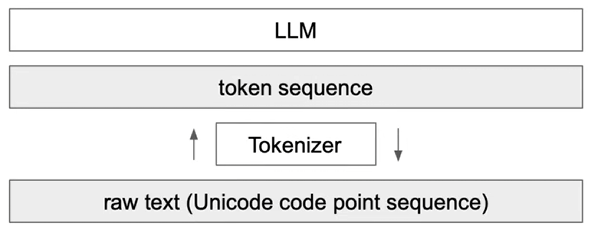

In [21]:
vocab = { idx : bytes([idx]) for idx in range(256)} # initialize the vocab with the original 256 tokens, where each token is just a single byte corresponding to its index e.g. vocab[104] = b'h' so in the dictionary {104 : b'h'}
for (idx1, idx2), new_idx in merges.items():
    vocab[new_idx] = vocab[idx1] + vocab[idx2] # the new token is the concatenation of the two tokens it merges


def decode(ids):
    text = bytes().join(vocab[idx] for idx in ids)
    return text.decode("utf-8", errors="replace") # decode the bytes back to a string, replacing any invalid sequences with the Unicode replacement character

decode(ids)

'Nathan Reed\nBlog Stuff I’ve Made Talks About Me\nThe Many Meanings of “Shader”Quadrilateral Interpolation, Part 2\nA Programmer’s Introduction to Unicode\nMarch 3, 2017 · Coding · 25 Comments\n\nＵｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺\u200c🇳\u200c🇮\u200c🇨\u200c🇴\u200c🇩\u200c🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception.\n\nA few months ago, I got interested in Unicode and decided to spend some time learning more about it in detail. In this article, I’ll give an introduction to it from a programmer’s point of view.\n\nI’m going to focus on the character se

In [ ]:
print(decode([128])) 

�


In [25]:
merges

{(101, 32): 256,
 (105, 110): 257,
 (115, 32): 258,
 (116, 104): 259,
 (101, 114): 260,
 (99, 111): 261,
 (116, 32): 262,
 (226, 128): 263,
 (44, 32): 264,
 (97, 110): 265,
 (111, 114): 266,
 (100, 32): 267,
 (97, 114): 268,
 (101, 110): 269,
 (257, 103): 270,
 (261, 100): 271,
 (121, 32): 272,
 (97, 108): 273,
 (111, 110): 274,
 (259, 256): 275}

In [ ]:
def encode(text):
    tokens = text.encode("utf-8")
    tokens = list(map(int, tokens)) # convert to list of integers for processing
    while len(tokens) > 2:
        stats = get_stats(tokens)
        pair = min(stats, key = lambda p: merges.get(p, float('inf'))) # find the pair with the smallest new index in merges (i.e. the most recently merged pair that still exists in the tokens) because we want to apply merges in the same order they were created because the merges are designed to be applied in that order for correct encoding
        
        if pair not in merges:
            break # nothing else can be merged, we’re done
        
        idx = merges[pair]
        tokens = merge_pair(tokens, pair, idx) # merge the pair in the tokens list
        
    return tokens

print(encode("h"))

[104]


In [33]:
print(decode(encode("hello world!")))

hello world!


In [34]:
text2 = decode(encode(text))

print(text2 == text)

True


In [37]:
valtext = "您好 🙏 (formal hello in Mandarin Chinese!)"
valtext2 = decode(encode(valtext))
print(valtext2 == valtext)

True


In [40]:
import regex as re

gpt2pat = re.compile(
    r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""
)

print(re.findall(gpt2pat, "Hello've world123 how's are you!!!?   "))

['Hello', "'ve", ' world', '123', ' how', "'s", ' are', ' you', '!!!?', '   ']


In [41]:
example = """
for i in range(1, 101):
    if i % 3 == 0 and i % 5 == 0:
        print("FizzBuzz")
    elif i % 3 == 0:
        print("Fizz")
    elif i % 5 == 0:
        print("Buzz")
    else:
        print(i)
"""

print(re.findall(gpt2pat, example))

['\n', 'for', ' i', ' in', ' range', '(', '1', ',', ' 101', '):', '\n   ', ' if', ' i', ' %', ' 3', ' ==', ' 0', ' and', ' i', ' %', ' 5', ' ==', ' 0', ':', '\n       ', ' print', '("', 'FizzBuzz', '")', '\n   ', ' elif', ' i', ' %', ' 3', ' ==', ' 0', ':', '\n       ', ' print', '("', 'Fizz', '")', '\n   ', ' elif', ' i', ' %', ' 5', ' ==', ' 0', ':', '\n       ', ' print', '("', 'Buzz', '")', '\n   ', ' else', ':', '\n       ', ' print', '(', 'i', ')', '\n']


In [2]:
import tiktoken

enc = tiktoken.get_encoding("gpt2")
print(enc.encode("    hello world!!!"))

enc = tiktoken.get_encoding("cl100k_base")
print(enc.encode("    hello world!!!"))

[220, 220, 220, 23748, 995, 10185]
[262, 24748, 1917, 12340]


In [ ]:
# !curl -O https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/vocab.bpe
# !curl -O https://openaipublic.blob.core.windows.net/gpt-2/models/1558M/encoder.json

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
 14 445.6k  14  65066   0      0  54618      0   00:08   00:01   00:07  54656
100 445.6k 100 445.6k   0      0 235.7k      0   00:01   00:01          54656
100 445.6k 100 445.6k   0      0 235.7k      0   00:01   00:01          54656
100 445.6k 100 445.6k   0      0 235.7k      0   00:01   00:01          54656
  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
  1  0.99M   1  15921   0      0  15480      0   01:07   00:01   01:06  15492
 42  0.99M  42 431.5k   0      0 197.4k      0   00:05   00:02   00:03 197.5k
100  0.99M 100  0.99M   0      0 383.9k      0   00:02   00:02

In [ ]:
import os, json

with open("encoder.json", 'r') as f:
    encoder = json.load(f) # similar to the vocab we created earlier
    
with open("vocab.bpe", 'r', encoding='utf-8') as f:
    bpe_data = f.read() # similar to the merges we created earlier
    
bpe_merges = [tuple(merge.split()) for merge in bpe_data.split("\n")[1:-1]] # skip the first line which is just a header, and the last line which is empty

In [ ]:
#special tokens

len(encoder) #256 raw byte tokens, 50,000 merges, +1 special token <|endoftext|> with index 50256

50257

In [4]:
encoder['<|endoftext|>'] # special token for end of text, used in GPT-2 to signify the end of a text sequence

50256

In [5]:
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")  # GPT-4 tokenizer

print(enc.encode("안녕하세요 👋 (hello in Korean!)"))

print(
    enc.decode(
        enc.encode("안녕하세요 👋 (hello in Korean!)")
    ) == "안녕하세요 👋 (hello in Korean!)"
)

# I need match the above for my own tokenizer,
# and also implement a train() function

[31495, 230, 75265, 243, 92245, 62904, 233, 320, 15339, 304, 16526, 16715]
True


In [6]:
enc.n_vocab

100277

In [1]:
class BasicTokenizer:
    def __init__(self):
        self.vocab = {}
        self.merges = {}
        self.reverse_vocab = {}
        
    def get_stats(self, ids):
        counts = {}
        for pair in zip(ids, ids[1:]):
            counts[pair] = counts.get(pair, 0) + 1
        
        return counts

    def merge_pair(self, ids, pair, new_idx):
        new_ids = []
        i = 0;
        
        while i<len(ids):
            
            if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1]==pair[1]:
                new_ids.append(new_idx)
                i+=2
            
            else:
                new_ids.append(ids[i])
                i+=1
        
        return new_ids

    def train(self, text, vocab_size, verbose=False):
        
        tokens = text.encode("utf-8")
        number_of_merges = vocab_size - 256
        ids = list(map(int, tokens)) # convert to list of integers for processing
        
        for i in range(number_of_merges):
            stats = self.get_stats(ids)
            
            if not stats:
                if verbose:
                    print("No more pairs to merge, stopping early.")
                break # no more pairs to merge
            
            top_pair = max(stats, key = stats.get)
            if verbose:
                print(f"Merging pair {top_pair} with new index {256 + i}, count: {stats[top_pair]}")
            ids = self.merge_pair(ids, top_pair, 256 + i)
            self.merges[top_pair] = 256 + i
        
        self.reverse_vocab = { idx : bytes([idx]) for idx in range(256)} # initialize the reverse vocab with the original 256 tokens, where each token is just a single byte corresponding to its index e.g. reverse_vocab[104] = b'h' so in the dictionary {104 : b'h'} and its technically a reverse vocab since it maps from token index to token bytes, but we can call it reverse_vocab for simplicity
        
        for (idx1, idx2), new_idx in self.merges.items():
            self.reverse_vocab[new_idx] = self.reverse_vocab[idx1] + self.reverse_vocab[idx2] # new token is concatenation of merged tokens

        self.vocab = {v : k for k,v in self.reverse_vocab.items()} # not needed for encoding since we can just use the merges to merge pairs in the input tokens, but could be useful for debugging or other purposes and we dont use it in this implementation since we can just use the merges to merge pairs in the input tokens, but could be useful for debugging or other purposes 
        
    def encode(self, text):
        tokens = text.encode("utf-8")
        ids = list(map(int, tokens)) # convert to list of integers for processing
        
        while len(ids) >= 2:
            stats = self.get_stats(ids)
            pair = min(stats, key = lambda p : self.merges.get(p, float('inf'))) # find the pair with the smallest new index in merges that still exists in ids because we need to apply merges in the same order they were created for correct encoding
            
            if pair not in self.merges:
                break # no more pairs to merge, we’re done
            
            ids = self.merge_pair(ids, pair, self.merges[pair]) # merge the pair in the ids list
        
        return ids
    
    def decode(self, ids):
        text = bytes().join(self.reverse_vocab.get(idx, b'') for idx in ids) # get the byte sequence for each token index and concatenate them, using an empty byte string for any unknown indices (shouldn’t happen if encoding was done with the same vocab)
        return text.decode("utf-8", errors="replace") # decode the bytes back to a string, replacing any invalid sequences with the Unicode replacement character
    

In [37]:
tokenizer = BasicTokenizer()

with open("taylorswift.txt", "r", encoding="utf-8") as f:
    text = f.read()

tokenizer.train(text, vocab_size=1000, verbose=True)

Merging pair (101, 32) with new index 256, count: 2981
Merging pair (44, 32) with new index 257, count: 2961
Merging pair (100, 32) with new index 258, count: 2617
Merging pair (46, 32) with new index 259, count: 2560
Merging pair (114, 32) with new index 260, count: 2428
Merging pair (50, 48) with new index 261, count: 2365
Merging pair (115, 32) with new index 262, count: 2053
Merging pair (105, 110) with new index 263, count: 2006
Merging pair (111, 110) with new index 264, count: 1815
Merging pair (114, 105) with new index 265, count: 1805
Merging pair (116, 32) with new index 266, count: 1802
Merging pair (116, 104) with new index 267, count: 1737
Merging pair (101, 258) with new index 268, count: 1736
Merging pair (257, 261) with new index 269, count: 1705
Merging pair (97, 110) with new index 270, count: 1487
Merging pair (97, 114) with new index 271, count: 1360
Merging pair (101, 260) with new index 272, count: 1356
Merging pair (121, 32) with new index 273, count: 1248
Mergin

In [38]:
text = "hello hello hello"

encoded = tokenizer.encode(text)
decoded = tokenizer.decode(encoded)

print(encoded)
print(encoded == tokenizer.encode(text)) # should be True
print(len(encoded))
print(decoded)

[104, 531, 369, 104, 531, 369, 104, 531, 111]
True
9
hello hello hello


In [39]:
text = "hello world!!!? (안녕하세요!) lol123 😉"

encoded = tokenizer.encode(text)
decoded = tokenizer.decode(encoded)

print(encoded)
print(encoded == tokenizer.encode(text)) # should be True
print(len(encoded))
print(decoded)

[104, 531, 369, 119, 650, 100, 33, 33, 33, 63, 400, 236, 149, 136, 235, 133, 149, 237, 149, 152, 236, 132, 184, 236, 154, 148, 33, 895, 108, 407, 49, 423, 32, 240, 159, 152, 137]
True
37
hello world!!!? (안녕하세요!) lol123 😉


In [ ]:
# match this
import tiktoken
enc = tiktoken.get_encoding("cl100k_base") # this is the GPT-4 tokenizer
ids = enc.encode("hello world!!!? (안녕하세요!) lol123 😉")
text = enc.decode(ids) # get the same text back
print(ids)
print(text)

[15339, 1917, 12340, 30, 320, 31495, 230, 75265, 243, 92245, 16715, 28509, 4513, 57037]
hello world!!!? (안녕하세요!) lol123 😉


In [10]:
text = "hello world!!!? (안녕하세요!) lol123 😉"

encoded = tokenizer.encode(text)
decoded = tokenizer.decode(encoded)

print(encoded)
print(decoded)

[104, 531, 369, 119, 650, 100, 33, 33, 33, 63, 400, 236, 149, 136, 235, 133, 149, 237, 149, 152, 236, 132, 184, 236, 154, 148, 33, 895, 108, 407, 49, 423, 32, 240, 159, 152, 137]
hello world!!!? (안녕하세요!) lol123 😉


In [ ]:
import regex as re

class RegexTokenizer:
    def __init__(self):
        self.vocab = {}
        self.merges = {}
        self.reverse_vocab = {}
        self.pattern = r"""'(?i:[sdmt]|ll|ve|re)|[^\r\n\p{L}\p{N}]?+\p{L}+|\p{N}{1,3}| ?[^\s\p{L}\p{N}]++[\r\n]*|\s*[\r\n]|\s+(?!\S)|\s+"""
        self.compiled_pattern = re.compile(self.pattern)
        
        
    def get_stats(self, ids, counts = None):
        counts = {} if counts is None else counts
        for pair in zip(ids, ids[1:]):
            counts[pair] = counts.get(pair, 0) + 1
        
        return counts

    def merge_pair(self, ids, pair, new_idx):
        new_ids = []
        i = 0
        
        while i<len(ids):
            
            if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1]==pair[1]:
                new_ids.append(new_idx)
                i+=2
            
            else:
                new_ids.append(ids[i])
                i+=1
        
        return new_ids

    def train(self, text, vocab_size, verbose=False):
        
        assert vocab_size >= 256, "vocab_size must be at least 256 to accommodate the initial byte tokens"
        number_of_merges = vocab_size - 256
        
        pattern = self.compiled_pattern
        
        token_chunks = pattern.findall(text) # use the regex pattern to split the text into tokens, which will be the initial tokens for the BPE algorithm
        # print(token_chunks)
        
        ids = [list(chunk.encode("utf-8")) for chunk in token_chunks] # convert each token chunk to bytes and then to a list of integers for processing
        
        # print(ids)
        
        # merges = {} # (int, int) -> int
        
        
        # initialize the reverse vocab with the original 256 tokens, where each token is just a single byte corresponding to its index e.g. reverse_vocab[104] = b'h' so in the dictionary {104 : b'h'} and its technically a reverse vocab since it maps from token index to token bytes, but we can call it reverse_vocab for simplicity
        self.reverse_vocab = { idx : bytes([idx]) for idx in range(256)} # idx -> bytes 
        
        for i in range(number_of_merges):
            # count the number of times every consecutive pair appears
            stats = {}
            
            for chunk_ids in ids:
                self.get_stats(chunk_ids, counts=stats) # get the stats for this chunk and add it to the overall stats for this iteration
                
            if not stats:
                if verbose:
                    print("No more pairs to merge, stopping early.")
                break # no more pairs to merge
            
            # find the pair with the highest count
            pair = max(stats, key = stats.get)
                
            idx = 256 + i
            
            # replace all occurrences of pair in ids with idx    
            ids = [self.merge_pair(chunk_ids, pair, idx) for chunk_ids in ids] # merge the pair in each chunk
            
            self.merges[pair] = idx
            self.reverse_vocab[idx] = self.reverse_vocab[pair[0]] + self.reverse_vocab[pair[1]] # new token is concatenation of merged tokens
            
            if verbose:
                print(f"merge {i+1}/{number_of_merges}: {pair} -> {idx} ({self.reverse_vocab[idx]}) had {stats[pair]} occurrences")

        
        self.vocab = {v : k for k,v in self.reverse_vocab.items()} # not needed for encoding since we can just use the merges to merge pairs in the input tokens, but could be useful for debugging or other purposes and we dont use it in this implementation since we can just use the merges to merge pairs in the input tokens, but could be useful for debugging or other purposes 
        
    def encode_chunks(self, chunk):
        
        chunk_ids = list(map(int, chunk)) # convert the chunk to a list of integers for processing
        
        while len(chunk_ids) >= 2:
                stats = self.get_stats(chunk_ids)
                pair = min(stats, key = lambda p : self.merges.get(p, float('inf'))) # find the pair with the smallest new index in merges that still exists in ids because we need to apply merges in the same order they were created for correct encoding
            
                if pair not in self.merges:
                    break # no more pairs to merge, we’re done
                
                # print(pair)
                
                chunk_ids = self.merge_pair(chunk_ids, pair, self.merges[pair]) # merge the pair in the ids list
        
        return chunk_ids

    def encode(self, text):
        
        token_chunks = self.compiled_pattern.findall(text) # use the regex pattern to split the text into tokens, which will be the initial tokens for the BPE algorithm
        
        ids = [] # all chunks of text are encoded separately, then results are joined
        
        for token_chunk in token_chunks:
            chunk_bytes = token_chunk.encode("utf-8") # convert the chunk to bytes
            chunk_ids = self.encode_chunks(chunk_bytes) # encode the chunk using the same merges that were learned during training, which will give us a list of token ids for this chunk
            ids.extend(chunk_ids) # add the token ids for this chunk to the overall list of token ids for the whole input text
        
        return ids
    
    def decode(self, ids):
        text = bytes().join(self.reverse_vocab[idx] for idx in ids) # get the byte sequence for each token index and concatenate them, using an empty byte string for any unknown indices (shouldn’t happen if encoding was done with the same vocab)
        return text.decode("utf-8", errors="replace") # decode the bytes back to a string, replacing any invalid sequences with the Unicode replacement character
    

In [7]:
regexTokenizer = RegexTokenizer()

with open("taylorswift.txt", "r", encoding="utf-8") as f:
    text = f.read()

regexTokenizer.train(text, vocab_size=1000, verbose=True)

['Copy', ' paste', ' of', ' the', ' Wikipedia', ' article', ' on', ' Taylor', ' Swift', ',', ' as', ' of', ' Feb', ' ', '16', ',', ' ', '202', '4', '.\n', '---\n\n', 'Main', ' menu', '\n\n', 'WikipediaThe', ' Free', ' Encyclopedia', '\n\n', 'Search', '\n', 'Create', ' account', '\n', 'Log', ' in', '\n\n', 'Personal', ' tools', '\n', 'Contents', ' ', ' hide', '\n', '(Top', ')\n', 'Life', ' and', ' career', '\n', 'Toggle', ' Life', ' and', ' career', ' subsection', '\n', 'Artistry', '\n', 'Toggle', ' Artistry', ' subsection', '\n', 'Accolades', ' and', ' achievements', '\n', 'Cultural', ' status', '\n', 'Toggle', ' Cultural', ' status', ' subsection', '\n', 'Wealth', '\n', 'Toggle', ' Wealth', ' subsection', '\n', 'Discography', '\n', 'Filmography', '\n', 'Tours', '\n', 'See', ' also', '\n', 'Footnotes', '\n', 'References', '\n', 'Toggle', ' References', ' subsection', '\n', 'External', ' links', '\n', 'Taylor', ' Swift', '\n\n', '136', ' languages', '\n', 'Article', '\n', 'Talk', '\n', 

In [8]:
text = "hello hello hello"

encoded = regexTokenizer.encode(text)  # fix encode and decode for regex logic
decoded = regexTokenizer.decode(encoded)

print(encoded)
print(encoded == regexTokenizer.encode(text)) # should be True
print(len(encoded))
print(decoded)

[263, 301, 111, 754, 301, 111, 754, 301, 111]
True
9
hello hello hello


In [9]:
text = "hello world!!!? (안녕하세요!) lol123 😉"

encoded = regexTokenizer.encode(text)
decoded = regexTokenizer.decode(encoded)

print(encoded)
print(encoded == regexTokenizer.encode(text)) # should be True
print(len(encoded))
print(decoded)

[263, 301, 111, 340, 606, 33, 33, 33, 63, 293, 236, 149, 136, 235, 133, 149, 237, 149, 152, 236, 132, 184, 236, 154, 148, 33, 41, 442, 412, 49, 484, 32, 240, 159, 152, 137]
True
36
hello world!!!? (안녕하세요!) lol123 😉


In [66]:
import tiktoken
enc = tiktoken.get_encoding("cl100k_base") # this is the GPT-4 tokenizer
ids = enc.encode("hello world!!!? (안녕하세요!) lol123 😉")
print(ids)
print(len(ids))
print(enc.decode(ids))
print(enc.n_vocab)

[15339, 1917, 12340, 30, 320, 31495, 230, 75265, 243, 92245, 16715, 28509, 4513, 57037]
14
hello world!!!? (안녕하세요!) lol123 😉
100277


In [ ]:
import tiktoken
enc = tiktoken.get_encoding("cl100k_base") # this is the GPT-4 tokenizer
ids = enc.encode("<|endoftext|>hello world", allowed_special="all")
print(ids)
print(enc.decode(ids))

## sentencepiece

Commonly used because (unlike tiktoken) it can efficiently both train and inference BPE tokenizers. It is used in both Llama and Mistral series.

[sentencepiece on Github link.](https://github.com/google/sentencepiece)

**The big difference:** sentencepiece runs BPE on the Unicode code points directly! It then has an option `character_coverage` for what to do with very rare codepoints that appear very few times, and it either maps them onto an UNK token, or if `byte_fallback` is turned on, it encodes them with utf-8 and then encodes the raw bytes instead.

TLDR:

- tiktoken encodes to utf-8 and then BPEs bytes
- sentencepiece BPEs the code points and optionally falls back to utf-8 bytes for rare code points (rarity is determined by `character_coverage` hyperparameter), which then get translated to byte tokens.

In [ ]:
import sentencepiece as spm

with open("toy.txt", "w", encoding="utf-8") as f:
    f.write(
        "SentencePiece is an unsupervised text tokenizer and detokenizer mainly for Neural Network-based text generation systems."
    )

In [9]:
# train a sentencepiece model on it
# the settings here are (best effort) those used for training Llama 2

import os

options = dict(
    # input spec
    input="toy.txt",
    input_format="text",

    # output spec
    model_prefix="tok400",  # output filename prefix

    # algorithm spec
    # BPE alg
    model_type="bpe",
    vocab_size=400,

    # normalization
    normalization_rule_name="identity",  # ew, turn off normalization
    remove_extra_whitespaces=False,

    input_sentence_size=200000000,  # max number of training sentences
    max_sentence_length=4192,  # max number of bytes per sentence
    seed_sentencepiece_size=1000000,
    shuffle_input_sentence=True,

    # rare word treatment
    character_coverage=0.99995,
    byte_fallback=True,

    # merge rules
    split_digits=True,
    split_by_unicode_script=True,
    split_by_whitespace=True,
    split_by_number=True,
    max_sentencepiece_length=16,
    add_dummy_prefix=True,
    allow_whitespace_only_pieces=True,

    # special tokens
    unk_id=0,  # the UNK token MUST exist
    bos_id=1,  # the others are optional, set to -1 to turn off
    eos_id=2,
    pad_id=-1,

    # systems
    num_threads=os.cpu_count(),  # use all system resources
)

spm.SentencePieceTrainer.train(**options)

In [11]:
sp = spm.SentencePieceProcessor()
sp.Load("tok400.model")
vocab = [[sp.id_to_piece(idx), idx] for idx in range(sp.GetPieceSize())]
vocab

[['<unk>', 0],
 ['<s>', 1],
 ['</s>', 2],
 ['<0x00>', 3],
 ['<0x01>', 4],
 ['<0x02>', 5],
 ['<0x03>', 6],
 ['<0x04>', 7],
 ['<0x05>', 8],
 ['<0x06>', 9],
 ['<0x07>', 10],
 ['<0x08>', 11],
 ['<0x09>', 12],
 ['<0x0A>', 13],
 ['<0x0B>', 14],
 ['<0x0C>', 15],
 ['<0x0D>', 16],
 ['<0x0E>', 17],
 ['<0x0F>', 18],
 ['<0x10>', 19],
 ['<0x11>', 20],
 ['<0x12>', 21],
 ['<0x13>', 22],
 ['<0x14>', 23],
 ['<0x15>', 24],
 ['<0x16>', 25],
 ['<0x17>', 26],
 ['<0x18>', 27],
 ['<0x19>', 28],
 ['<0x1A>', 29],
 ['<0x1B>', 30],
 ['<0x1C>', 31],
 ['<0x1D>', 32],
 ['<0x1E>', 33],
 ['<0x1F>', 34],
 ['<0x20>', 35],
 ['<0x21>', 36],
 ['<0x22>', 37],
 ['<0x23>', 38],
 ['<0x24>', 39],
 ['<0x25>', 40],
 ['<0x26>', 41],
 ['<0x27>', 42],
 ['<0x28>', 43],
 ['<0x29>', 44],
 ['<0x2A>', 45],
 ['<0x2B>', 46],
 ['<0x2C>', 47],
 ['<0x2D>', 48],
 ['<0x2E>', 49],
 ['<0x2F>', 50],
 ['<0x30>', 51],
 ['<0x31>', 52],
 ['<0x32>', 53],
 ['<0x33>', 54],
 ['<0x34>', 55],
 ['<0x35>', 56],
 ['<0x36>', 57],
 ['<0x37>', 58],
 ['<0x38>', 5

In [12]:
ids = sp.encode("안녕하세요 👋 (hello in Korean!)")
print(ids)

[326, 239, 152, 139, 238, 136, 152, 240, 152, 155, 239, 135, 187, 239, 157, 151, 326, 243, 162, 148, 142, 275, 264, 272, 332, 268, 326, 365, 332, 266, 294, 36, 352]


In [13]:
print([sp.id_to_piece(idx) for idx in ids])

['▁', '<0xEC>', '<0x95>', '<0x88>', '<0xEB>', '<0x85>', '<0x95>', '<0xED>', '<0x95>', '<0x98>', '<0xEC>', '<0x84>', '<0xB8>', '<0xEC>', '<0x9A>', '<0x94>', '▁', '<0xF0>', '<0x9F>', '<0x91>', '<0x8B>', '▁(', 'he', 'll', 'o', '▁in', '▁', 'K', 'o', 're', 'an', '<0x21>', ')']


# Llama 2 Tokenizer Proto

If you'd like to export the raw protocol buffer for the `tokenizer.model` released by Meta, this is the result:

```proto
normalizer_spec {
  name: "identity"
  precompiled_charsmap: ""
  add_dummy_prefix: true
  remove_extra_whitespaces: false
  normalization_rule_tsv: ""
}

trainer_spec {
  input: "/large_experiments/theorem/datasets/MERGED/all.test1.merged"
  model_prefix: "spm_model_32k_200M_charcov099995_allowWSO__v2"
  model_type: BPE
  vocab_size: 32000
  self_test_sample_size: 0
  input_format: "text"
  character_coverage: 0.99995
  input_sentence_size: 200000000
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  num_threads: 80
  num_sub_iterations: 2
  max_sentence_length: 4192
  shuffle_input_sentence: true
  max_sentencepiece_length: 16
  split_by_unicode_script: true
  split_by_whitespace: true
  split_by_number: true
  treat_whitespace_as_suffix: false
  split_digits: true
  allow_whitespace_only_pieces: true
  vocabulary_output_piece_score: true
  hard_vocab_limit: true
  use_all_vocab: false
  byte_fallback: true
  required_chars: ""
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_surface: " \342\201\207 "
  unk_piece: "<unk>"
  bos_piece: "<s>"
  eos_piece: "</s>"
  pad_piece: "<pad>"
  train_extremely_large_corpus: false
  enable_differential_privacy: false
  differential_privacy_noise_level: 0.0
  differential_privacy_clipping_threshold: 0
}
```

# vocab_size

- **Q:** what should be vocab size?
- **Q:** how can I increase vocab size?
- **A:** by learning/adding more tokens during tokenizer training (ex: more BPE merges)

---

A very large vocabulary becomes computationally expensive because:

1. **Embedding tables grow larger**

   The input embedding matrix size is:

   \[
   V \times d_{model}
   \]

   where:
   - \(V\) = vocab size
   - \(d_{model}\) = embedding dimension

2. **Output softmax layer also grows**
   - The model must predict probabilities over the entire vocabulary for every generated token.

3. **More parameters**
   - Larger vocab = more embedding parameters + larger output projection matrices.

4. **Some tokens become undertrained**
   - Rare tokens appear very infrequently, so their embeddings do not receive enough gradient updates.

---

## Tokenization Tradeoff

The tokenization process also changes with vocab size.

In BPE, a larger vocabulary creates larger token chunks through additional merges.

Example:

Small vocab:

```text
"machine" + "learning"
```

Larger vocab:

```text
"machinelearning"
```

Too many merges may create overly specific tokens:

```text
"machinelearningmodel"
```

This can hurt the model because:

- the model loses compositional understanding
- giant tokens appear less frequently
- embeddings for rare giant tokens become undertrained
- the tokenizer starts memorizing chunks instead of learning reusable patterns

---

## Tradeoff Summary

### Small vocabulary

```text
"u" "n" "b" "e" "l" "i" "e" "v" "a" "b" "l" "e"
```

Pros:
- better compositionality
- reusable subword pieces

Cons:
- much longer sequences
- higher attention cost

---

### Large vocabulary

```text
"unbelievable"
```

Pros:
- shorter sequences
- more efficient attention computation

Cons:
- poorer generalization if tokens become too specific
- sparse training signal for rare tokens

---

## Final Idea

Tokenizer design is a balancing act between:

- computational efficiency
- sequence length
- compositionality
- multilingual support
- training frequency per token

This is why modern LLMs usually use vocab sizes around:

- 32k
- 50k
- 100k-ish

instead of millions of whole-word tokens.